ARTI308 - Machine Learning

# Linear Regression on Ecommerce Customers


## 1) Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

## 2) Load the Dataset

In [2]:
customers = pd.read_csv('Ecommerce Customers')
customers.head()

,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\nCobbborough, D...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David Throughway\nPort Jason, OH 22070-1220",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\nPort Jacobville, PR 3...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092


## 3) Explore the Data

In [3]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    object 
 1   Address               500 non-null    object 
 2   Avatar                500 non-null    object 
 3   Avg. Session Length   500 non-null    float64
 4   Time on App           500 non-null    float64
 5   Time on Website       500 non-null    float64
 6   Length of Membership  500 non-null    float64
 7   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5), object(3)
memory usage: 31.4+ KB


In [4]:
customers.describe()

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,33.053194,12.052488,37.060445,3.533462,499.314038
std,0.992563,0.994216,1.010489,0.999278,79.314782
min,29.532429,8.508152,33.913847,0.269901,256.670582
25%,32.341822,11.388153,36.349257,2.930450,445.038277
50%,33.082008,11.983231,37.069367,3.533975,498.887875
75%,33.711985,12.753850,37.716432,4.126502,549.313828
max,36.139662,15.126994,40.005182,6.922689,765.518462


In [5]:
customers.columns

Index(['Email', 'Address', 'Avatar', 'Avg. Session Length', 'Time on App',
       'Time on Website', 'Length of Membership', 'Yearly Amount Spent'],
      dtype='object')

## 4) Data Cleaning

Check for:
- Missing values
- Duplicate rows
- Data types


In [6]:
customers.isnull().sum()

Email                   0
Address                 0
Avatar                  0
Avg. Session Length     0
Time on App             0
Time on Website         0
Length of Membership    0
Yearly Amount Spent     0
dtype: int64

In [7]:
customers.duplicated().sum()

np.int64(0)

No missing values or duplicated rows were found, so the dataset is clean.

## 5) Exploratory Data Analysis (EDA)

Create a few plots to understand relationships between the numeric variables.


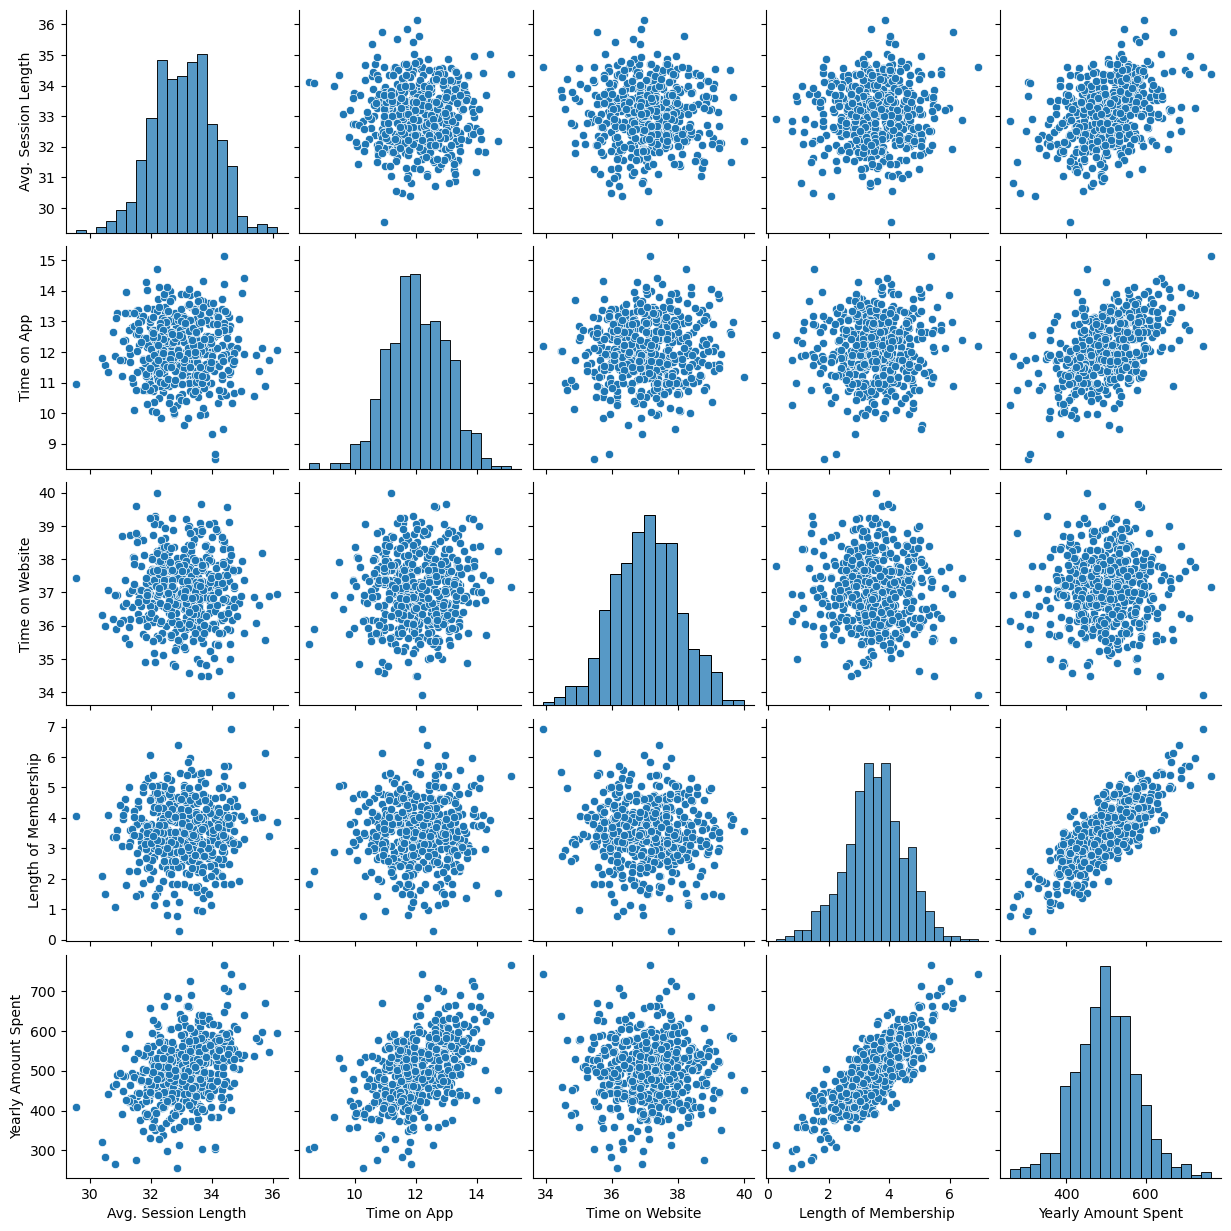

In [8]:
sns.pairplot(customers)

<Axes: xlabel='Yearly Amount Spent', ylabel='Count'>

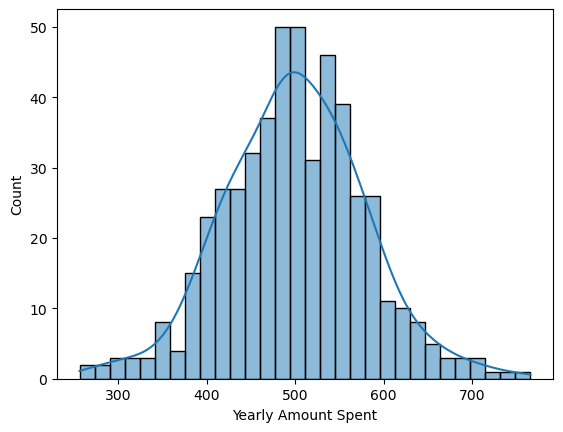

In [9]:
sns.histplot(customers['Yearly Amount Spent'], bins=30, kde=True)

<Axes: >

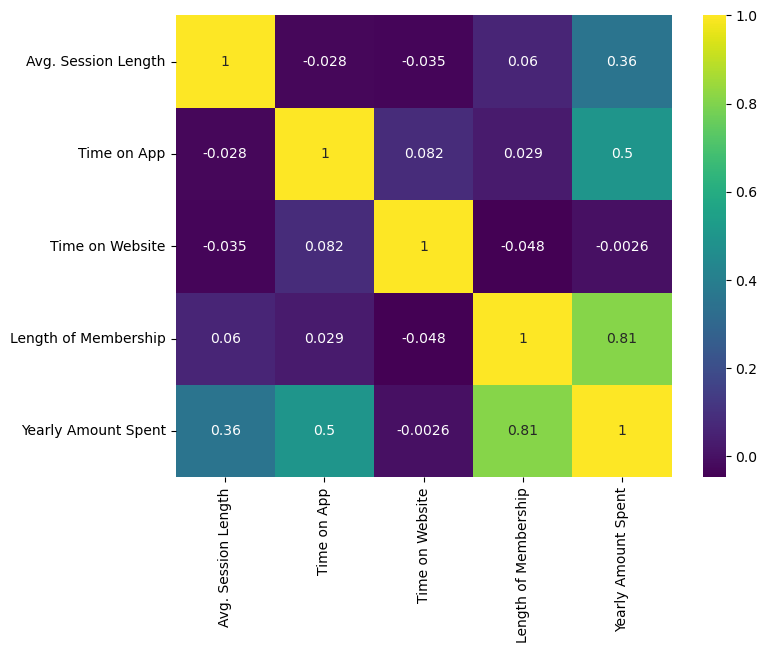

In [10]:
plt.figure(figsize=(8,6))
sns.heatmap(customers.corr(numeric_only=True), annot=True, cmap='viridis')

### Observation

`Length of Membership` and `Time on App` appear to have strong positive relationships with `Yearly Amount Spent`.


## 6) Feature Selection

We will use the numeric customer behavior features as input variables, and predict:

- **Target (y):** `Yearly Amount Spent`

We will exclude:
- `Email`
- `Address`
- `Avatar`

because they are text/categorical fields and are not used in this simple linear regression model.


In [11]:
X = customers[['Avg. Session Length', 'Time on App', 'Time on Website', 'Length of Membership']]
y = customers['Yearly Amount Spent']

## 7) Train-Test Split

In [12]:
from sklearn.model_selection import train_test_split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, random_state=101
)

## 8) Create and Train the Linear Regression Model

In [14]:
from sklearn.linear_model import LinearRegression

In [15]:
lm = LinearRegression()

In [16]:
lm.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## 9) Model Evaluation

In [17]:
print('Intercept:', lm.intercept_)

Intercept: -1045.1152168245753


In [18]:
coeff_df = pd.DataFrame(lm.coef_, X.columns, columns=['Coefficient'])
coeff_df

,Coefficient
Avg. Session Length,25.691540
Time on App,37.892600
Time on Website,0.560581
Length of Membership,61.648594


### Interpretation of Coefficients

- Holding all other features fixed, a 1 unit increase in **Avg. Session Length** is associated with an increase of about **25.69** dollars in yearly spending.
- Holding all other features fixed, a 1 unit increase in **Time on App** is associated with an increase of about **37.89** dollars in yearly spending.
- Holding all other features fixed, a 1 unit increase in **Time on Website** is associated with an increase of about **0.56** dollars in yearly spending.
- Holding all other features fixed, a 1 unit increase in **Length of Membership** is associated with an increase of about **61.65** dollars in yearly spending.

This suggests that **Length of Membership** is the strongest predictor among these features.


## 10) Predictions

In [19]:
predictions = lm.predict(X_test)

Text(0.5, 1.0, 'Actual vs Predicted')

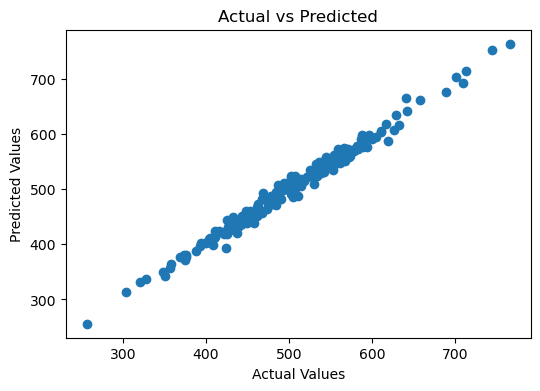

In [20]:
plt.figure(figsize=(6,4))
plt.scatter(y_test, predictions)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted')

## 11) Residuals

Text(0.5, 1.0, 'Residual Distribution')

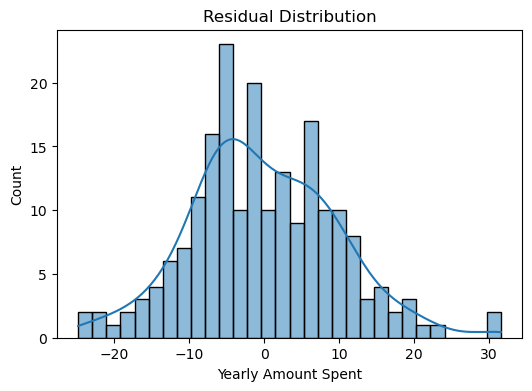

In [21]:
plt.figure(figsize=(6,4))
sns.histplot((y_test - predictions), bins=30, kde=True)
plt.title('Residual Distribution')

## 12) Regression Evaluation Metrics

In [22]:
from sklearn import metrics

In [23]:
print('MAE:', metrics.mean_absolute_error(y_test, predictions))
print('MSE:', metrics.mean_squared_error(y_test, predictions))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, predictions)))

MAE: 7.7426712858387425
MSE: 93.83297800820114
RMSE: 9.68674238370161


## 13) Final Conclusion

The Linear Regression model performs well on the Ecommerce Customers dataset.

Key findings:
- **Length of Membership** has the strongest effect on yearly spending.
- **Time on App** also has a meaningful positive impact.
- **Time on Website** has a much smaller effect compared to the app.

This may suggest that customers engage more effectively through the **mobile app** than the website.
